# 03 — Scoreline Model

Fits `penaltyblog`'s Dixon-Coles and Bivariate-Poisson goal models and compares them on a held-out season. One fitted model's `FootballProbabilityGrid` gives 1X2, exact scorelines, BTTS, and over/under goals all at once.

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')

from pl_predictor.features.build import build_training_frame
from pl_predictor.models.manifest import chronological_split
from pl_predictor.models import scoreline

df, feature_cols = build_training_frame()
train_df, val_df = chronological_split(df)
print(f'train={len(train_df)}  val={len(val_df)} (held-out season: {val_df["season"].iloc[0]})')

train=2660  val=380 (held-out season: 2025-2026)


In [2]:
dc_model = scoreline.fit_dixon_coles(train_df)
bp_model = scoreline.fit_bivariate_poisson(train_df)
print(dc_model)

Module: Penaltyblog

Model: Dixon and Coles

Number of parameters: 60
Log Likelihood: -1827.256
AIC: 3774.512

Team                 Attack               Defence             
------------------------------------------------------------
Arsenal              1.445                -1.293              
Aston Villa          1.236                -0.919              
Bournemouth          1.112                -0.869              
Brentford            1.245                -0.843              
Brighton             1.238                -0.822              
Burnley              0.81                 -0.654              
Cardiff              0.647                -0.606              
Chelsea              1.285                -1.008              
Crystal Palace       1.084                -0.924              
Everton              0.848                -1.016              
Fulham               1.112                -0.859              
Huddersfield         0.222                -0.491              
Ipswich  

## Compare on the held-out season

In [3]:
from pl_predictor.evaluate.calibration import model_calibration, bookmaker_calibration, naive_favourite_baseline

print('Dixon-Coles:      ', model_calibration(dc_model, val_df))
print('Bivariate-Poisson:', model_calibration(bp_model, val_df))
print('Bookmaker (Shin): ', bookmaker_calibration(val_df))
print('Naive baseline:   ', naive_favourite_baseline(val_df))

Dixon-Coles:       {'rps': 0.21174679330247168, 'brier': 0.6230608640119022, 'ignorance': 1.4948684808959103, 'n_matches': 380}
Bivariate-Poisson: {'rps': 0.21174117458922193, 'brier': 0.6228347455229235, 'ignorance': 1.494074796652214, 'n_matches': 380}
Bookmaker (Shin):  {'rps': 0.20599368621693048, 'brier': 0.6123372139372185, 'ignorance': 1.4706234690437985, 'n_matches': 380}
Naive baseline:    {'rps': 0.22790263157894672, 'brier': 0.6551473684210545, 'n_matches': 380}


Lower RPS/Brier is better. The chosen model should land close to (not dramatically worse than) the bookmaker baseline, and clearly beat the naive baseline.

## Example fixture prediction + scoreline heatmap

Home 55.7%  Draw 23.4%  Away 20.9%
BTTS yes: 52.3%  Over 2.5: 52.2%
Most likely scorelines: [{'home': 1, 'away': 0, 'prob': 0.11127616628309239}, {'home': 1, 'away': 1, 'prob': 0.11118976539971522}, {'home': 2, 'away': 0, 'prob': 0.09901773185402062}, {'home': 2, 'away': 1, 'prob': 0.09819248559417675}, {'home': 0, 'away': 0, 'prob': 0.06342380735104312}]


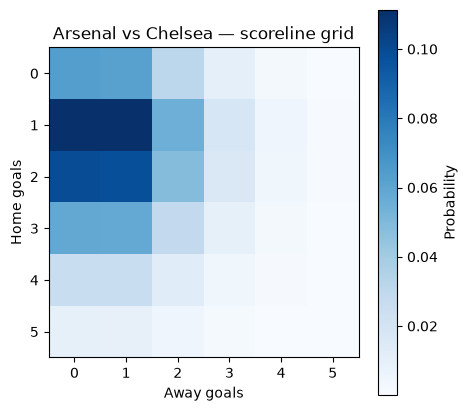

In [4]:
import matplotlib.pyplot as plt

pred = scoreline.predict_fixture(dc_model, 'Arsenal', 'Chelsea')
print(f"Home {pred['home_win']:.1%}  Draw {pred['draw']:.1%}  Away {pred['away_win']:.1%}")
print('BTTS yes:', f"{pred['btts_yes']:.1%}", ' Over 2.5:', f"{pred['over_2_5']:.1%}")
print('Most likely scorelines:', pred['top_scorelines'])

plt.figure(figsize=(5, 5))
plt.imshow(pred['grid'][:6, :6], cmap='Blues')
plt.xlabel('Away goals'); plt.ylabel('Home goals'); plt.title('Arsenal vs Chelsea — scoreline grid')
plt.colorbar(label='Probability')
plt.show()

## Save the trained models

Run `python -m pl_predictor.models.manifest` (or notebook 04, which calls the same `train_all()`) to train + save everything, including the market models, in one go.

## ml_scoreline — XGBoost expected-goals regressors (production default as of this session)

Dixon-Coles/Bivariate-Poisson above fit team-level attack/defence parameters directly from goals. `ml_scoreline` instead feeds the full engineered feature set (rolling form, Elo/Pi, referee, xG) into two XGBoost regressors — one for home goals, one for away — then prices markets the same way, via `penaltyblog.models.create_dixon_coles_grid`. It's the model actually serving predictions in the app right now because it beat both DC and BP here.

In [5]:
from pl_predictor.models import ml_scoreline

X_train, X_val = train_df[feature_cols].fillna(0), val_df[feature_cols].fillna(0)
ml_home_model, ml_away_model = ml_scoreline.train_goal_regressors(X_train, train_df['goals_home'], train_df['goals_away'])
ml_metrics = ml_scoreline.evaluate_on_holdout(ml_home_model, ml_away_model, X_val, val_df)

import pandas as pd
comparison = pd.DataFrame(
    [
        {'model': 'Dixon-Coles', **model_calibration(dc_model, val_df)},
        {'model': 'Bivariate-Poisson', **model_calibration(bp_model, val_df)},
        {'model': 'ml_scoreline (XGBoost)', 'rps': ml_metrics['rps'], 'brier': ml_metrics['brier'], 'ignorance': None, 'n_matches': len(val_df)},
        {'model': 'Bookmaker (Shin)', **bookmaker_calibration(val_df)},
    ]
).set_index('model')
comparison

,rps,brier,ignorance,n_matches
model,,,,
Dixon-Coles,0.211747,0.623061,1.494868,380
Bivariate-Poisson,0.211741,0.622835,1.494075,380
ml_scoreline (XGBoost),0.207304,0.615884,NaN,380
Bookmaker (Shin),0.205994,0.612337,1.470623,380


## Feature importance — SHAP, permutation, gain

Same three views the app's Calibration page shows. SHAP (via XGBoost's own exact TreeSHAP, `pred_contribs=True` — no separate `shap` package needed) decomposes every prediction into how much each feature pushed it up or down from the average, kept *signed* so direction is visible — pink pushes the prediction up, blue pushes it down. Usually the most intuitive of the three at a glance, since gain/permutation are both magnitude-only training-time scores rather than grounded in actual per-prediction effects.

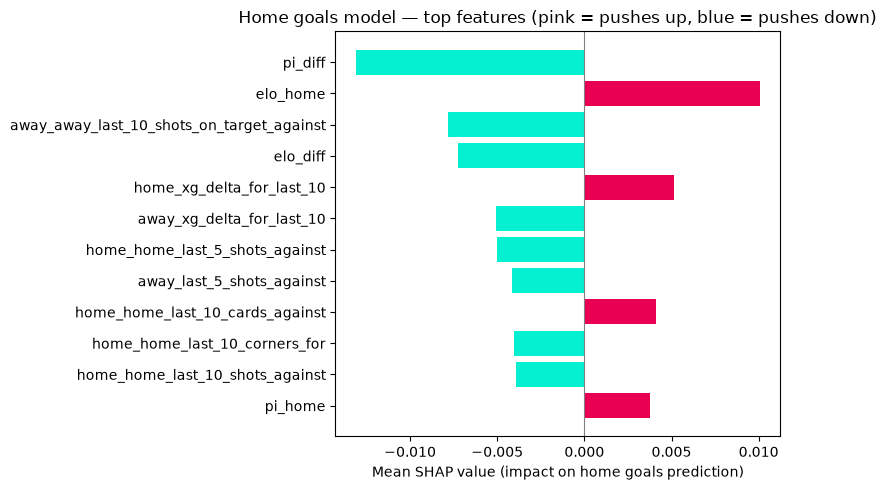

In [6]:
import numpy as np
import xgboost as xgb

def shap_signed(model, X, feature_cols, top_n=12):
    dmatrix = xgb.DMatrix(X, feature_names=feature_cols)
    contribs = model.get_booster().predict(dmatrix, pred_contribs=True)
    mean_signed = contribs[:, :-1].mean(axis=0)  # last column is the bias/expected-value term
    s = pd.Series(mean_signed, index=feature_cols).reindex(
        pd.Series(mean_signed, index=feature_cols).abs().sort_values(ascending=False).index
    )
    return s.head(top_n)

home_shap = shap_signed(ml_home_model, X_val, feature_cols)

plt.figure(figsize=(8, 5))
colors = ['#E90052' if v >= 0 else '#05f0d1' for v in home_shap.values[::-1]]
plt.barh(range(len(home_shap)), home_shap.values[::-1], color=colors)
plt.yticks(range(len(home_shap)), home_shap.index[::-1])
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel('Mean SHAP value (impact on home goals prediction)')
plt.title('Home goals model — top features (pink = pushes up, blue = pushes down)')
plt.tight_layout()
plt.show()